In [1]:
!nvidia-smi

Mon Feb  9 04:36:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os

In [9]:
img=image.load_img('/content/drive/MyDrive/Colab Notebooks/CNN_Project/test/pic1.jfif')

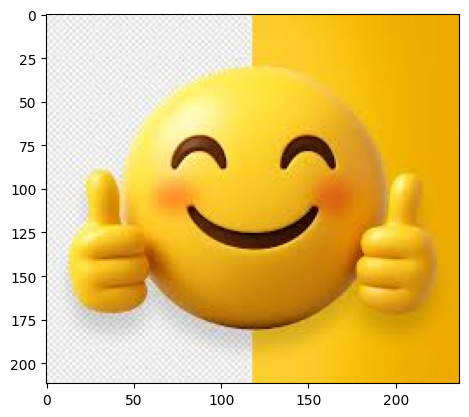

In [10]:
plt.imshow(img)

array([[[253, 253, 253],
        [247, 247, 247],
        [231, 231, 231],
        ...,
        [  3, 169, 238],
        [  3, 169, 238],
        [  3, 169, 238]],

       [[252, 252, 252],
        [247, 247, 247],
        [220, 220, 220],
        ...,
        [  3, 169, 238],
        [  3, 169, 238],
        [  3, 169, 238]],

       [[224, 224, 224],
        [230, 230, 230],
        [250, 250, 250],
        ...,
        [  3, 169, 238],
        [  3, 169, 238],
        [  3, 169, 238]],

       ...,

       [[233, 233, 233],
        [241, 241, 241],
        [240, 240, 240],
        ...,
        [  3, 169, 238],
        [  3, 169, 238],
        [  3, 169, 238]],

       [[224, 224, 224],
        [226, 226, 226],
        [248, 248, 248],
        ...,
        [  3, 169, 238],
        [  3, 169, 238],
        [  3, 169, 238]],

       [[235, 235, 235],
        [230, 230, 230],
        [243, 243, 243],
        ...,
        [  3, 169, 238],
        [  3, 169, 238],
        [  3, 169, 238]]], dtype=uint8)
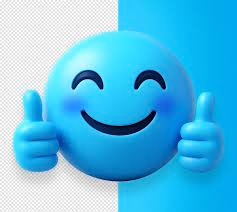

In [13]:
i1=cv2.imread('/content/drive/MyDrive/Colab Notebooks/CNN_Project/test/pic1.jfif')
i1

In [14]:
i1.shape

(212, 237, 3)

In [26]:
train=ImageDataGenerator(rescale=1/200) # In the training folder all the images are not of the same size
validation=ImageDataGenerator(rescale=1/200)
test=ImageDataGenerator(rescale=1/200)

In [27]:
train_dataset=train.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/CNN_Project/train',
                                        target_size=(200,200),
                                        batch_size=32,
                                        class_mode='binary')

validation_dataset=validation.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/CNN_Project/validation',
                                         target_size=(200,200),
                                        batch_size=32,
                                        class_mode='binary')
#test_dataset=test.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/CNN_Project/test',)

Found 29 images belonging to 3 classes.
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.


In [24]:
train_dataset.class_indices

{'.ipynb_checkpoints': 0, 'happy': 1, 'sad': 2}

In [25]:
train_dataset.classes

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [30]:
model=tf.keras.models.Sequential([tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(200,200,3)),
                                 tf.keras.layers.MaxPool2D(2,2),
                                 tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
                                 tf.keras.layers.MaxPool2D(2,2),
                                  tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
                                 tf.keras.layers.MaxPool2D(2,2),
                                 tf.keras.layers.Flatten(),
                                 tf.keras.layers.Dense(512,activation='relu'),
                                 tf.keras.layers.Dense(1,activation='sigmoid')
                                 ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(loss="binary_crossentropy",optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),metrics=['accuracy'] )

In [37]:
model_fit=model.fit(train_dataset,epochs=3)

Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.4828 - loss: 0.5670
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step - accuracy: 0.4828 - loss: -70.2672
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.4828 - loss: -339.6751


In [38]:
dir_path='/content/drive/MyDrive/Colab Notebooks/CNN_Project/test'
for i in os.listdir(dir_path):
  print(i)

pic1.jfif
pic2.jfif
pic3.jfif
pic4.jfif
pic5.jfif
pic6.jfif
pic7.jpg
pic8.webp
pic9.jpg
pic10.jpg


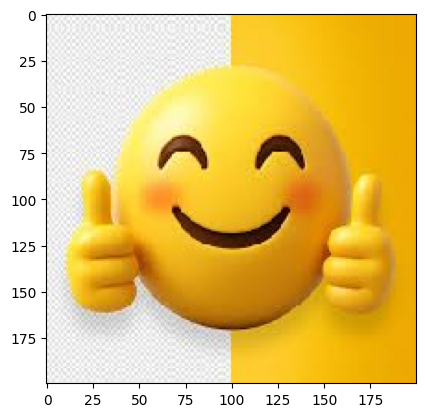

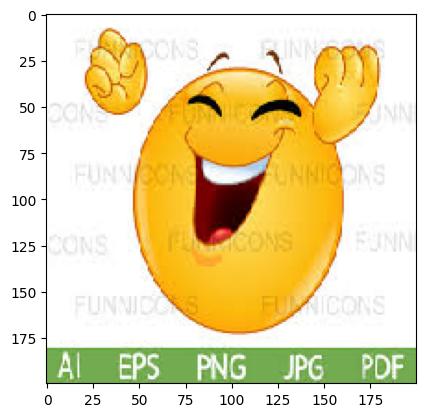

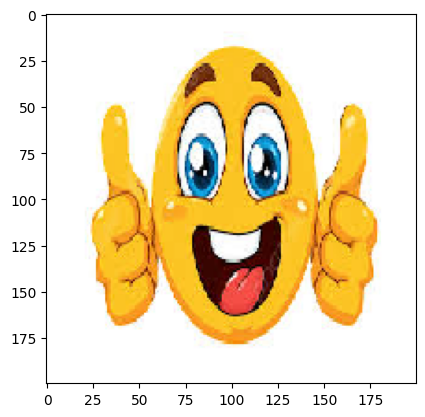

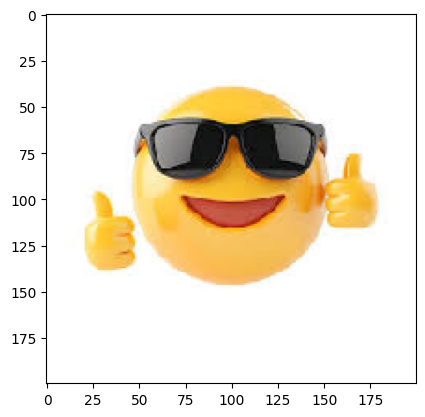

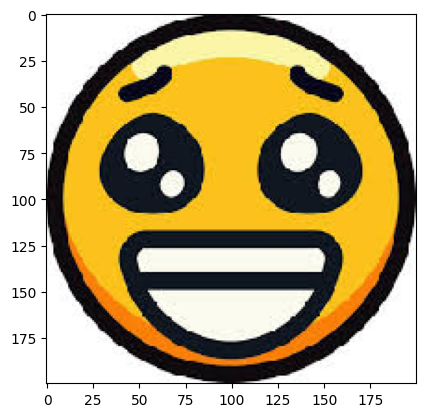

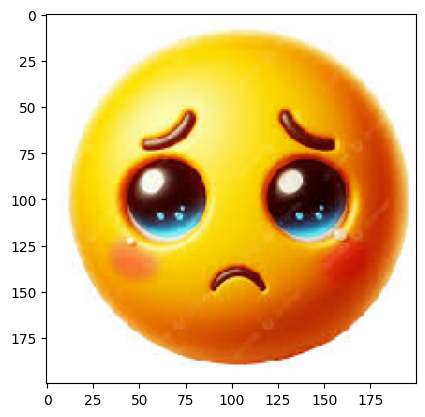

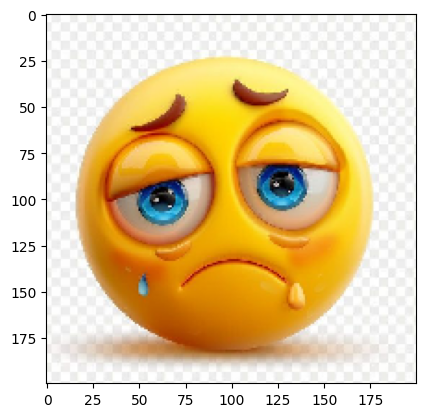

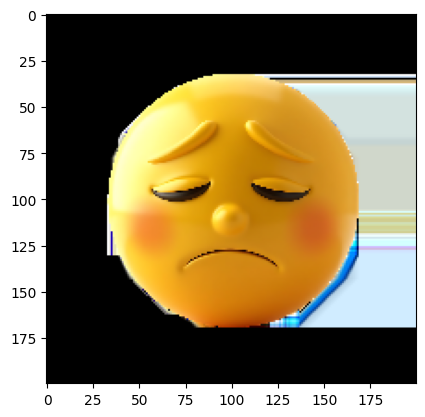

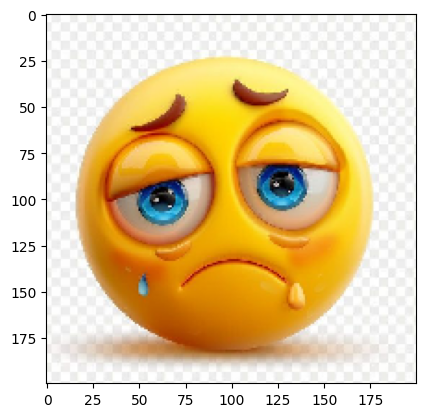

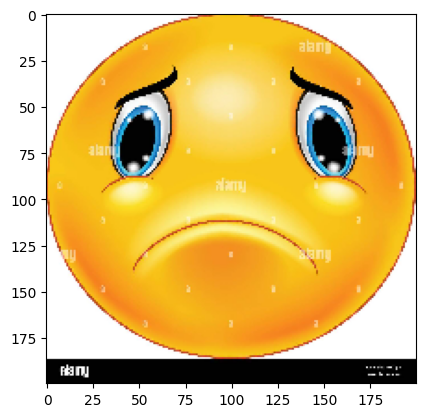

In [39]:
dir_path='/content/drive/MyDrive/Colab Notebooks/CNN_Project/test'
for i in os.listdir(dir_path):
  img=image.load_img(dir_path+'//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

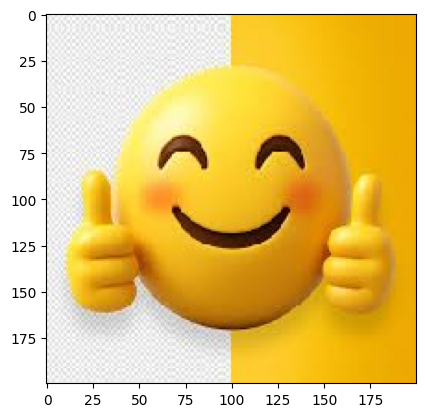

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
i am sad


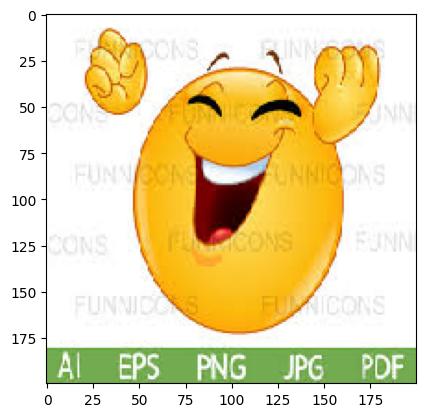

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
i am sad


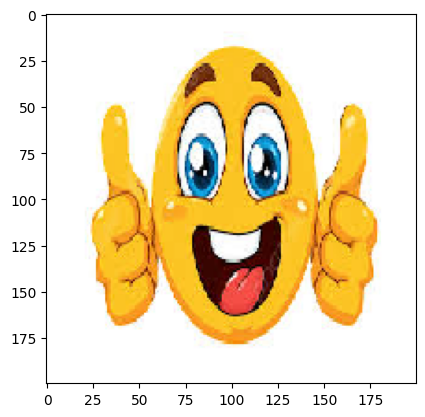

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
i am sad


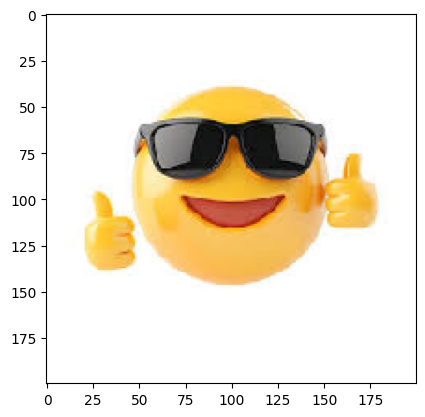

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
i am sad


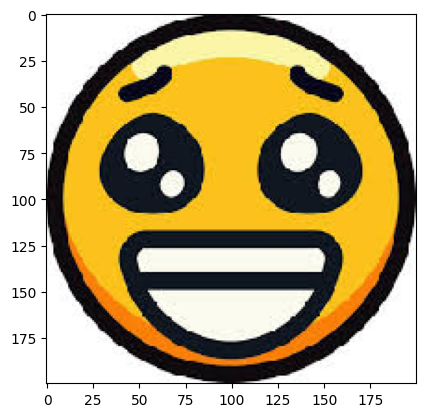

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
i am sad


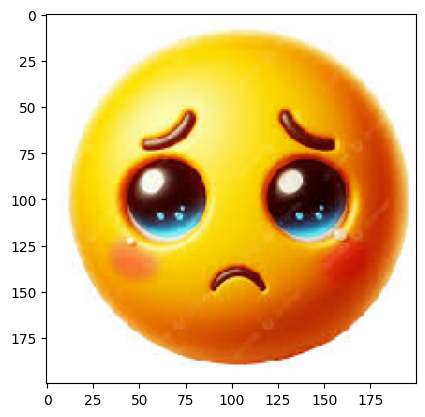

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
i am sad


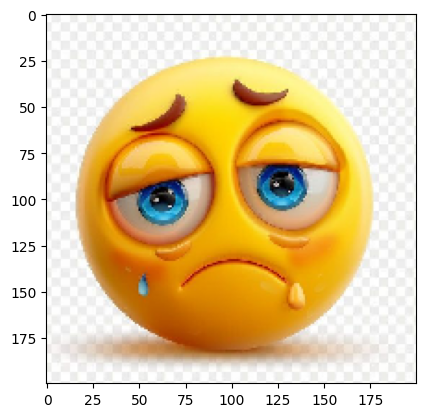

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
i am sad


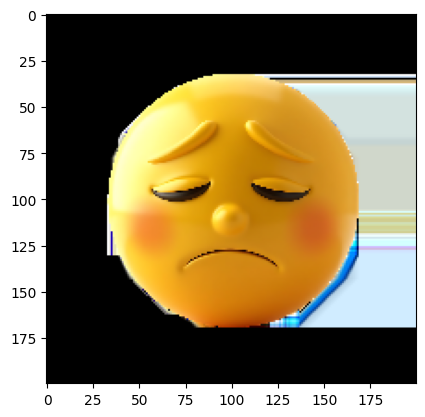

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
i am sad


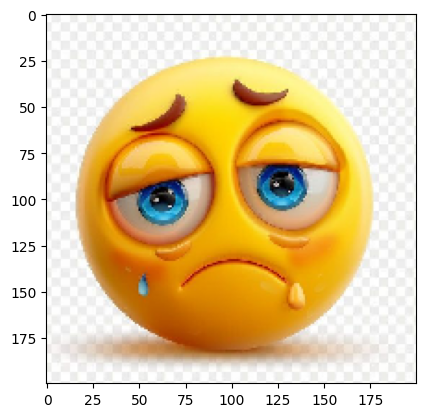

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
i am sad


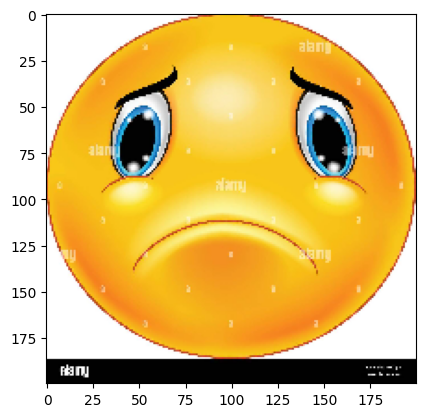

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
i am sad


In [41]:
dir_path='/content/drive/MyDrive/Colab Notebooks/CNN_Project/test'
for i in os.listdir(dir_path):
  img=image.load_img(dir_path+'//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()
  x=image.img_to_array(img)
  x=np.expand_dims(x,axis=0)
  images=np.vstack([x])
  val=model.predict(images)
  if val==0:
    print('i am happy')
  else:
    print('i am sad')

frontend creation using gradio and python function

In [48]:
import gradio as gr
from PIL import Image
import numpy as np


def predict_mood(image):
  img=image.resize((200,200))
  X=np.array(img)
  X=np.expand_dims(x,axis=0)
  X=X/200.0
  val=model.predict(x)[0][0]
  if val<0.5:
    return 'Happy'
  else:
    return 'Sad'

In [49]:
iface=gr.Interface(fn=predict_mood,inputs=gr.Image(type="pil",label="Upload an image"),
                  outputs=gr.Text(label="Predicted Mood"),
                  title="Mood Classification(Happy/Not Happy)",
                  description="Upload an image to classify if the person is happy or not happy")
iface.launch(share=True,show_error=True,debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8d764b45edf1dd349d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
